YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Removed 54 rows corresponding to ex-dividend and earnings dates.
Null values in each column:
 Price        Ticker
Close        BK        0
High         BK        0
Low          BK        0
Open         BK        0
Volume       BK        0
20MA                   0
50MA                   0
RSI                    0
12EMA                  0
26EMA                  0
MACD                   0
Signal_Line            0
Upper_BB               0
Lower_BB               0
CCI                    0
ATR                    0
Williams_%R            0
OBV                    0
dtype: int64
Does the dataset contain any null values? False

Running baseline Linear Regression for indicators: ['20MA', 'RSI', 'MACD', 'Upper_BB', 'Lower_BB', 'OBV'], Window: 5, Forecast: 1

=== Train Metrics ===
RMSE: 0.0108, MAPE: 6142631332125.0977, R2: 0.9895, Acc: 77.8746, ProfitIdx: 2435.1591

=== Validation Metrics ===
RMSE: 0.0149, MAPE: 3.4752, R2: 0.9790, Acc: 76.4228, ProfitIdx: 1.2533

=== Test Metrics ===
RMSE: 0.0124

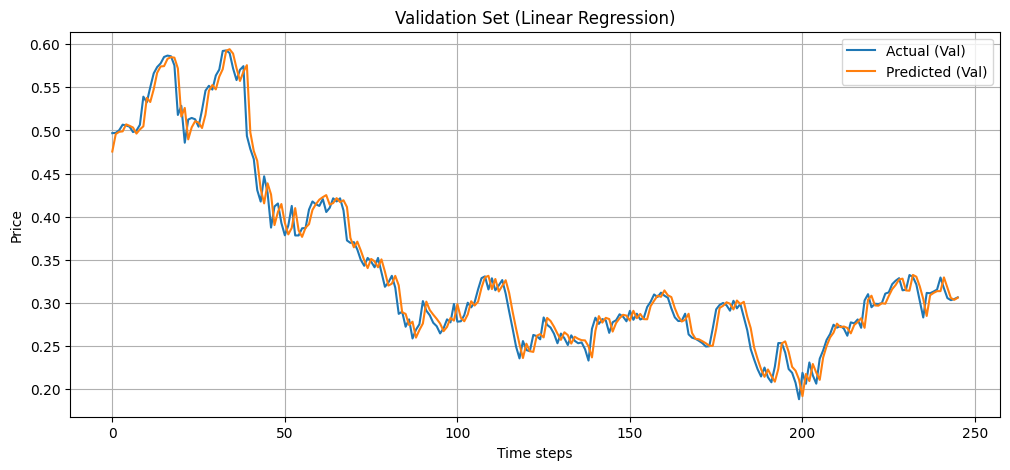

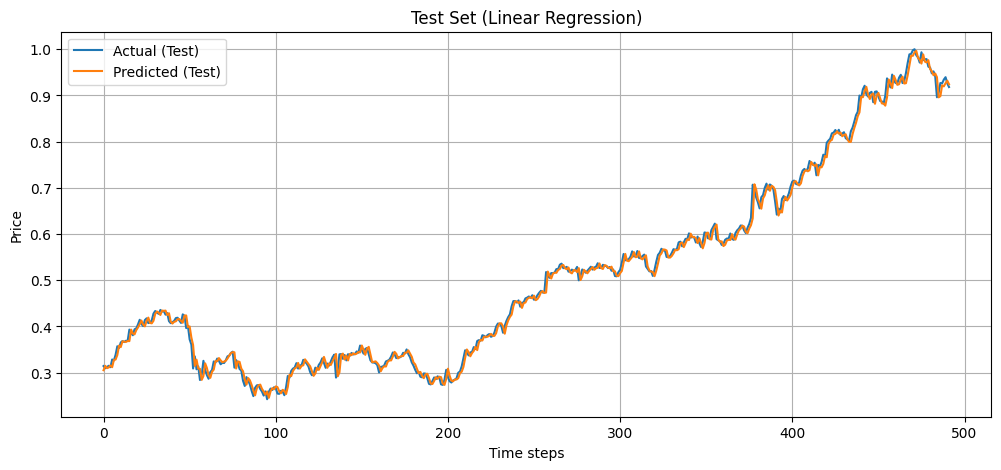

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

if "__file__" in globals():
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
else:
    project_root = os.path.abspath("..")
sys.path.append(project_root)

from ReusableFunctions.DataPreprocessing import DataPreprocessing
from ReusableFunctions.EvaluationMetrics import EvaluationMetrics as EM
from reproducibility_settings import set_global_seed

# -------------------
# Reproducibility
# -------------------
set_global_seed(seed=42, framework='numpy')

# -------------------
# Train & evaluate
# -------------------
def train_and_evaluate_linear_model(X_train, y_train, X_val, y_val, X_test, y_test, scaler_y, forecast_window):
    # Flatten inputs (samples, features)
    n_train, win, feat = X_train.shape
    n_val, _, _ = X_val.shape
    n_test, _, _ = X_test.shape

    X_train_flat = X_train.reshape(n_train, -1)
    X_val_flat   = X_val.reshape(n_val, -1)
    X_test_flat  = X_test.reshape(n_test, -1)

    # Fit baseline linear regression
    model = LinearRegression()
    model.fit(X_train_flat, y_train)

    # Predictions
    train_preds_scaled = model.predict(X_train_flat)
    val_preds_scaled   = model.predict(X_val_flat)
    test_preds_scaled  = model.predict(X_test_flat)

    # Inverse transform
    train_preds_unscaled = scaler_y.inverse_transform(train_preds_scaled.reshape(-1,1))
    val_preds_unscaled   = scaler_y.inverse_transform(val_preds_scaled.reshape(-1,1))
    test_preds_unscaled  = scaler_y.inverse_transform(test_preds_scaled.reshape(-1,1))

    y_train_unscaled = scaler_y.inverse_transform(y_train.reshape(-1,1))
    y_val_unscaled   = scaler_y.inverse_transform(y_val.reshape(-1,1))
    y_test_unscaled  = scaler_y.inverse_transform(y_test.reshape(-1,1))

    def compute_metrics(y_true, y_pred):
        r2 = EM.r2(y_true, y_pred)
        if np.isnan(r2) or np.isinf(r2):
            return np.nan, np.nan, np.nan, np.nan, np.nan
        return (
            EM.rmse(y_true, y_pred),
            EM.mape(y_true, y_pred),
            r2,
            EM.accuracy(y_true, y_pred),
            EM.profitability_index(y_true, y_pred, forecast_window)
        )

    train_metrics = compute_metrics(y_train_unscaled, train_preds_unscaled)
    val_metrics   = compute_metrics(y_val_unscaled, val_preds_unscaled)
    test_metrics  = compute_metrics(y_test_unscaled, test_preds_unscaled)

    # ---- Print
    print("\n=== Train Metrics ===")
    print(f"RMSE: {train_metrics[0]:.4f}, MAPE: {train_metrics[1]:.4f}, R2: {train_metrics[2]:.4f}, "
          f"Acc: {train_metrics[3]:.4f}, ProfitIdx: {train_metrics[4]:.4f}")
    print("\n=== Validation Metrics ===")
    print(f"RMSE: {val_metrics[0]:.4f}, MAPE: {val_metrics[1]:.4f}, R2: {val_metrics[2]:.4f}, "
          f"Acc: {val_metrics[3]:.4f}, ProfitIdx: {val_metrics[4]:.4f}")
    print("\n=== Test Metrics ===")
    print(f"RMSE: {test_metrics[0]:.4f}, MAPE: {test_metrics[1]:.4f}, R2: {test_metrics[2]:.4f}, "
          f"Acc: {test_metrics[3]:.4f}, ProfitIdx: {test_metrics[4]:.4f}")

    # ---- Plot
    plt.figure(figsize=(12,5))
    plt.plot(y_val_unscaled, label='Actual (Val)')
    plt.plot(val_preds_unscaled, label='Predicted (Val)')
    plt.title("Validation Set (Linear Regression)")
    plt.xlabel("Time steps")
    plt.ylabel("Price")
    plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(12,5))
    plt.plot(y_test_unscaled, label='Actual (Test)')
    plt.plot(test_preds_unscaled, label='Predicted (Test)')
    plt.title("Test Set (Linear Regression)")
    plt.xlabel("Time steps")
    plt.ylabel("Price")
    plt.legend(); plt.grid(True); plt.show()

    return train_metrics, val_metrics, test_metrics

# -------------------
# Main execution
# -------------------
if __name__ == '__main__':
    ticker = 'BK'
    window_size, forecast_window = 5, 1
    fixed_indicators = ['20MA','RSI','MACD','Upper_BB','Lower_BB','OBV']

    data_processor = DataPreprocessing(ticker=ticker, start_date='2014-01-01', end_date='2024-12-31')
    df = data_processor.add_technical_indicators()

    selected_features = ['Close'] + fixed_indicators
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[selected_features])
    X, y = data_processor.create_windowed_data(scaled_data, window_size, forecast_window)

    # ---- 70:10:20 split using DataPreprocessing ----
    X_train, X_val, X_test, y_train, y_val, y_test = data_processor.split_dataset(X, y, train_size=0.7, val_size=0.1)

    scaler_y = MinMaxScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
    y_val_scaled   = scaler_y.transform(y_val.reshape(-1,1))
    y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))

    print(f"\nRunning baseline Linear Regression for indicators: {fixed_indicators}, "
          f"Window: {window_size}, Forecast: {forecast_window}")

    train_and_evaluate_linear_model(
        X_train, y_train_scaled,
        X_val, y_val_scaled,
        X_test, y_test_scaled,
        scaler_y,
        forecast_window
    )
